In [4]:
from datasetEmociones import *
from transformer import *
from torch.utils.data import Dataset, DataLoader
import numpy as np
from utils import *
import matplotlib.pyplot as plt

In [5]:
train_transformer_dataset = EmotionDataset(ANNOTATIONS_FILE,
                AUDIO_DIR, 
                data_portion='train',
                transform=fft_transform
                )

val_transformer_dataset = EmotionDataset(ANNOTATIONS_FILE,
                AUDIO_DIR, 
                data_portion='validation',
                transform=fft_transform
                )

Época: 1
LOSS train 17.0654296875 valid 14.265486717224121
Modelo guardado en epoca 1
Época: 2
LOSS train 11.799860000610352 valid 9.728426933288574
Modelo guardado en epoca 2
Época: 3
LOSS train 7.377460479736328 valid 5.614778995513916
Modelo guardado en epoca 3
Época: 4
LOSS train 4.030824184417725 valid 2.8277626037597656
Modelo guardado en epoca 4
Época: 5
LOSS train 2.085698127746582 valid 1.5692745447158813
Modelo guardado en epoca 5
Época: 6
LOSS train 1.3102631568908691 valid 1.146986722946167
Modelo guardado en epoca 6
Época: 7
LOSS train 1.0694844722747803 valid 1.0366135835647583
Modelo guardado en epoca 7
Época: 8
LOSS train 1.0106133222579956 valid 1.0073034763336182
Modelo guardado en epoca 8
Época: 9
LOSS train 0.9967320561408997 valid 1.0052886009216309
Modelo guardado en epoca 9
Época: 10
LOSS train 0.9936169981956482 valid 1.0101847648620605
Época: 11
LOSS train 0.9950950145721436 valid 1.006344199180603
Época: 12
LOSS train 0.9956810474395752 valid 1.014122962951660

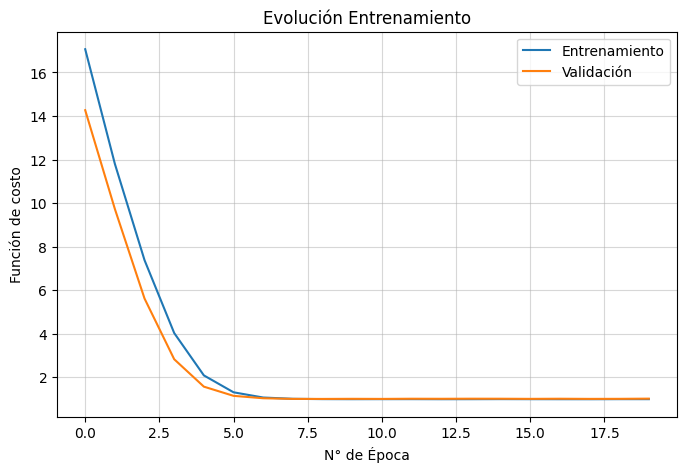

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# modelo
model = FFTTransformer(D_pos_emb=50, nhead=1).to(device)

# hiperparámetros
learning_rate = 1e-4
batch_size = 64
epochs = 20

# nombre de archivo con parametros
parameters_file = 'FFTTransformer_params_50_1.pt'

# funcion de perdida
loss_fn = nn.MSELoss()

# optimizador
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# dataloaders
train_dataloader = DataLoader(train_transformer_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_transformer_dataset, batch_size=batch_size, shuffle=True)

# listas para almacenar la evolución del loss en train y validacion
train_loss_evol = []
val_loss_evol = []

# se inicializan variables del entrenamiento
best_vloss = np.inf

# loop de entrenamiento
for epoch in range(epochs):
    print(f'Época: {epoch + 1}')

    # se realiza el entrenamiento
    model.train()
    avg_loss = train_one_epoch(model, train_dataloader, optimizer, loss_fn, device)

    # se evalua el modelo en validacion
    model.eval()
    avg_vloss = get_val_loss(model, val_dataloader, loss_fn, device)

    # se guardan e imprimen los loss de entrenamiento y validacion
    train_loss_evol.append(avg_loss)
    val_loss_evol.append(avg_vloss)
    print(f'LOSS train {avg_loss} valid {avg_vloss}')

    # se guarda el mejor modelo considerando la loss en validacion
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        # se guardan los parametros con menor loss en validacion
        torch.save(model.state_dict(), parameters_file)
        print(f'Modelo guardado en epoca {epoch+1}')

# se grafica la evolucion de la funcion de costo a lo largo de las epocas
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(train_loss_evol, label = 'Entrenamiento')
ax.plot(val_loss_evol, label = 'Validación')
ax.set(xlabel='N° de Época', ylabel='Función de costo', title='Evolución Entrenamiento')
ax.grid(alpha = 0.5)
ax.legend()
plt.show()

Época: 1
LOSS train 15.63383674621582 valid 12.678801536560059
Modelo guardado en epoca 1
Época: 2
LOSS train 9.892586708068848 valid 7.891351222991943
Modelo guardado en epoca 2
Época: 3
LOSS train 5.847102165222168 valid 4.1724853515625
Modelo guardado en epoca 3
Época: 4
LOSS train 2.930377960205078 valid 2.0808804035186768
Modelo guardado en epoca 4
Época: 5
LOSS train 1.5556703805923462 valid 1.267858862876892
Modelo guardado en epoca 5
Época: 6
LOSS train 1.1050493717193604 valid 1.050271987915039
Modelo guardado en epoca 6
Época: 7
LOSS train 1.0095775127410889 valid 1.0128062963485718
Modelo guardado en epoca 7
Época: 8
LOSS train 0.9982424378395081 valid 1.0148357152938843
Época: 9
LOSS train 0.9945699572563171 valid 1.0155696868896484
Época: 10
LOSS train 0.9962109923362732 valid 1.0100141763687134
Modelo guardado en epoca 10
Época: 11
LOSS train 0.9934113025665283 valid 1.0118364095687866
Época: 12
LOSS train 0.9940813183784485 valid 1.0084855556488037
Modelo guardado en epo

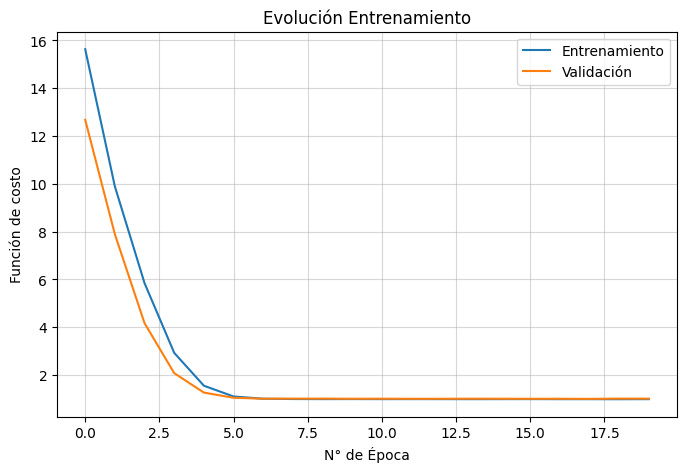

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# modelo
model = FFTTransformer(D_pos_emb=50, nhead=2).to(device)

# hiperparámetros
learning_rate = 1e-4
batch_size = 64
epochs = 20

# nombre de archivo con parametros
parameters_file = 'FFTTransformer_params_50_2.pt'

# funcion de perdida
loss_fn = nn.MSELoss()

# optimizador
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# dataloaders
train_dataloader = DataLoader(train_transformer_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_transformer_dataset, batch_size=batch_size, shuffle=True)

# listas para almacenar la evolución del loss en train y validacion
train_loss_evol = []
val_loss_evol = []

# se inicializan variables del entrenamiento
best_vloss = np.inf

# loop de entrenamiento
for epoch in range(epochs):
    print(f'Época: {epoch + 1}')

    # se realiza el entrenamiento
    model.train()
    avg_loss = train_one_epoch(model, train_dataloader, optimizer, loss_fn, device)

    # se evalua el modelo en validacion
    model.eval()
    avg_vloss = get_val_loss(model, val_dataloader, loss_fn, device)

    # se guardan e imprimen los loss de entrenamiento y validacion
    train_loss_evol.append(avg_loss)
    val_loss_evol.append(avg_vloss)
    print(f'LOSS train {avg_loss} valid {avg_vloss}')

    # se guarda el mejor modelo considerando la loss en validacion
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        # se guardan los parametros con menor loss en validacion
        torch.save(model.state_dict(), parameters_file)
        print(f'Modelo guardado en epoca {epoch+1}')

# se grafica la evolucion de la funcion de costo a lo largo de las epocas
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(train_loss_evol, label = 'Entrenamiento')
ax.plot(val_loss_evol, label = 'Validación')
ax.set(xlabel='N° de Época', ylabel='Función de costo', title='Evolución Entrenamiento')
ax.grid(alpha = 0.5)
ax.legend()
plt.show()